# Permutation Structural Similarity Analysis

**Purpose:** Assess how structurally similar degree-preserving permutations are to the original Hetionet and to each other.

## Research Questions

1. **Are degree sequences perfectly preserved?** (Expected: YES for XSwap algorithm)
2. **Are degree distributions identical across permutations?**
3. **How similar are edge counts?**
4. **Are there systematic differences between permutation groups?**
   - Perm 000 (Hetionet) vs 001-020 (training set)
   - Perm 000 vs 021-030 (validation set)
   - Perm 000 vs all 200 permutations
5. **Are permutations similar to each other?**

## Methodology

The XSwap algorithm preserves the **degree sequence** (each node keeps exactly the same degree) while randomizing **which edges exist**. This analysis verifies that property holds and quantifies structural similarity.

**Edge Type Analyzed:** AeG (Anatomy-expresses-Gene)

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import ks_2samp, ttest_rel
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance
import networkx as nx
from tqdm import tqdm
import json
import warnings
warnings.filterwarnings('ignore')

repo_dir = Path.cwd().parent
data_dir = repo_dir / 'data'
results_dir = repo_dir / 'results' / 'permutation_similarity'
results_dir.mkdir(parents=True, exist_ok=True)

print(f"Repository: {repo_dir}")
print(f"Results will be saved to: {results_dir}")

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Repository: /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability
Results will be saved to: /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/permutation_similarity


## 1. Configuration

In [2]:
EDGE_TYPE = 'AeG'

HETIONET_ID = 0
TRAINING_PERMS = list(range(1, 21))       # Perms 001-020 (20 perms)
VALIDATION_PERMS = list(range(21, 31))    # Perms 021-030 (10 perms)
REMAINING_PERMS = list(range(31, 51))     # Perms 031-050 (20 perms)

ALL_PERMS_TO_ANALYZE = [HETIONET_ID] + TRAINING_PERMS + VALIDATION_PERMS + REMAINING_PERMS

print(f"Edge Type: {EDGE_TYPE}")
print(f"\nPermutation Groups:")
print(f"  Hetionet (reference): {HETIONET_ID:03d}")
print(f"  Training set: {TRAINING_PERMS[0]:03d}-{TRAINING_PERMS[-1]:03d} (n={len(TRAINING_PERMS)})")
print(f"  Validation set: {VALIDATION_PERMS[0]:03d}-{VALIDATION_PERMS[-1]:03d} (n={len(VALIDATION_PERMS)})")
print(f"  Remaining set: {REMAINING_PERMS[0]:03d}-{REMAINING_PERMS[-1]:03d} (n={len(REMAINING_PERMS)})")
print(f"\nTotal permutations to analyze: {len(ALL_PERMS_TO_ANALYZE)}")

Edge Type: AeG

Permutation Groups:
  Hetionet (reference): 000
  Training set: 001-020 (n=20)
  Validation set: 021-030 (n=10)
  Remaining set: 031-050 (n=20)

Total permutations to analyze: 51


## 2. Load Edge Matrices

In [3]:
def load_edge_matrix(edge_type: str, perm_id: int) -> sp.csr_matrix:
    """
    Load edge matrix for given edge type and permutation.
    
    Parameters
    ----------
    edge_type : str
        Edge type code (e.g., 'AeG')
    perm_id : int
        Permutation ID (0 for Hetionet, 1-200 for permutations)
    
    Returns
    -------
    scipy.sparse.csr_matrix
        Sparse adjacency matrix
    """
    edge_file = data_dir / 'permutations' / f'{perm_id:03d}.hetmat' / 'edges' / f'{edge_type}.sparse.npz'
    return sp.load_npz(edge_file)

def extract_graph_stats(matrix: sp.csr_matrix, perm_id: int) -> dict:
    """
    Extract comprehensive graph statistics from edge matrix.
    
    Parameters
    ----------
    matrix : scipy.sparse.csr_matrix
        Edge matrix
    perm_id : int
        Permutation ID
    
    Returns
    -------
    dict
        Graph statistics including degrees, edge count, distribution moments
    """
    source_degrees = np.array(matrix.sum(axis=1)).flatten()
    target_degrees = np.array(matrix.sum(axis=0)).flatten()
    
    all_degrees = np.concatenate([source_degrees, target_degrees])
    
    return {
        'perm_id': perm_id,
        'n_edges': matrix.nnz,
        'n_source_nodes': matrix.shape[0],
        'n_target_nodes': matrix.shape[1],
        'source_degrees': source_degrees,
        'target_degrees': target_degrees,
        'source_degree_mean': source_degrees.mean(),
        'source_degree_std': source_degrees.std(),
        'source_degree_max': source_degrees.max(),
        'source_degree_min': source_degrees.min(),
        'target_degree_mean': target_degrees.mean(),
        'target_degree_std': target_degrees.std(),
        'target_degree_max': target_degrees.max(),
        'target_degree_min': target_degrees.min(),
        'all_degree_mean': all_degrees.mean(),
        'all_degree_std': all_degrees.std(),
        'all_degree_skew': pd.Series(all_degrees).skew(),
        'all_degree_kurtosis': pd.Series(all_degrees).kurtosis()
    }

print(f"Loading {len(ALL_PERMS_TO_ANALYZE)} permutations...\n")

permutation_data = {}

for perm_id in tqdm(ALL_PERMS_TO_ANALYZE, desc="Loading permutations"):
    matrix = load_edge_matrix(EDGE_TYPE, perm_id)
    stats = extract_graph_stats(matrix, perm_id)
    permutation_data[perm_id] = stats

print(f"\nLoaded {len(permutation_data)} permutations successfully!")
print(f"\nPermutation 000 (Hetionet):")
het_stats = permutation_data[HETIONET_ID]
print(f"  Shape: ({het_stats['n_source_nodes']}, {het_stats['n_target_nodes']})")
print(f"  Edges: {het_stats['n_edges']:,}")
print(f"  Source degree: {het_stats['source_degree_mean']:.2f} ± {het_stats['source_degree_std']:.2f}")
print(f"  Target degree: {het_stats['target_degree_mean']:.2f} ± {het_stats['target_degree_std']:.2f}")

Loading 51 permutations...



Loading permutations: 100%|██████████| 51/51 [00:00<00:00, 91.96it/s]


Loaded 51 permutations successfully!

Permutation 000 (Hetionet):
  Shape: (402, 20945)
  Edges: 526,407
  Source degree: 1309.47 ± 3111.43
  Target degree: 25.13 ± 20.49


## 3. Degree Sequence Preservation Analysis

XSwap should preserve **exact degree** for every node. We verify this by comparing degree sequences.

In [4]:
print("Analyzing degree sequence preservation...\n")

het_source_degrees = permutation_data[HETIONET_ID]['source_degrees']
het_target_degrees = permutation_data[HETIONET_ID]['target_degrees']

degree_preservation_results = []

for perm_id in ALL_PERMS_TO_ANALYZE[1:]:
    perm_source_degrees = permutation_data[perm_id]['source_degrees']
    perm_target_degrees = permutation_data[perm_id]['target_degrees']
    
    source_diff = het_source_degrees - perm_source_degrees
    target_diff = het_target_degrees - perm_target_degrees
    
    all_diff = np.concatenate([source_diff, target_diff])
    
    perfect_match_count = (all_diff == 0).sum()
    total_nodes = len(all_diff)
    perfect_match_pct = 100 * perfect_match_count / total_nodes
    
    degree_preservation_results.append({
        'perm_id': perm_id,
        'perfect_match_pct': perfect_match_pct,
        'mean_abs_deviation': np.abs(all_diff).mean(),
        'max_abs_deviation': np.abs(all_diff).max(),
        'std_deviation': all_diff.std()
    })

preservation_df = pd.DataFrame(degree_preservation_results)

print("="*80)
print("DEGREE SEQUENCE PRESERVATION ANALYSIS")
print("="*80)
print(f"\nAcross {len(preservation_df)} permutations:")
print(f"  Mean perfect match rate: {preservation_df['perfect_match_pct'].mean():.4f}%")
print(f"  Min perfect match rate: {preservation_df['perfect_match_pct'].min():.4f}%")
print(f"  Mean absolute deviation: {preservation_df['mean_abs_deviation'].mean():.6f}")
print(f"  Max absolute deviation: {preservation_df['max_abs_deviation'].max():.1f}")

if preservation_df['perfect_match_pct'].min() == 100.0:
    print(f"\nPERFECT DEGREE PRESERVATION!")
    print(f"   Every node has identical degree in all permutations")
    print(f"   XSwap algorithm working correctly")
else:
    print(f"\nDEGREE PRESERVATION ISSUES DETECTED")
    print(f"   Some nodes have different degrees")
    problematic = preservation_df[preservation_df['perfect_match_pct'] < 100.0]
    print(f"   Permutations with issues: {list(problematic['perm_id'].values)}")

Analyzing degree sequence preservation...

DEGREE SEQUENCE PRESERVATION ANALYSIS

Across 50 permutations:
  Mean perfect match rate: 100.0000%
  Min perfect match rate: 100.0000%
  Mean absolute deviation: 0.000000
  Max absolute deviation: 0.0

PERFECT DEGREE PRESERVATION!
   Every node has identical degree in all permutations
   XSwap algorithm working correctly


## 3.5. Bipartite Degree Correlation Analysis

Degree correlation measures whether high-degree source nodes tend to connect to high-degree target nodes (positive correlation) or to low-degree target nodes (negative correlation). This is the bipartite analogue of assortativity for heterogeneous networks.

**Interpretation:**
- r > 0: Assortative-like mixing (high-degree connects to high-degree)
- r = 0: Non-assortative (no correlation between endpoint degrees)
- r < 0: Disassortative-like mixing (high-degree connects to low-degree)

**Expected for XSwap**: Degree correlation should vary across permutations (indicating proper edge randomization) while maintaining a similar mean (indicating the null model preserves degree mixing patterns).

**Why this matters**: Edge probability models (RF, Poly, Analytical) assume P(u,v) depends on deg(u) and deg(v). This correlation quantifies that dependency.

**References:**
- Guillaume JL, Latapy M (2006) Bipartite graphs as models of complex networks. Physica A 371(2): 795-813.
- Barber MJ (2007) Modularity and community detection in bipartite networks. Phys Rev E 76:066102.
- Newman MEJ (2003) Mixing patterns in networks. Phys Rev E 67:026126.

In [5]:
def compute_bipartite_degree_correlation(matrix: sp.csr_matrix) -> float:
    """
    Compute degree correlation between source and target nodes.
    
    For bipartite networks, this measures whether high-degree source nodes
    tend to connect to high-degree target nodes (positive correlation) or
    to low-degree target nodes (negative correlation).
    
    This is the bipartite analogue of assortativity for heterogeneous networks.
    Works for both square (homogeneous) and non-square (bipartite) adjacency matrices.
    
    Parameters
    ----------
    matrix : scipy.sparse.csr_matrix
        Sparse adjacency matrix (can be non-square for bipartite graphs)
    
    Returns
    -------
    float
        Pearson correlation coefficient of degree pairs at edges
        Range: -1 (disassortative-like) to +1 (assortative-like)
    
    References
    ----------
    Guillaume JL, Latapy M (2006) Bipartite graphs as models of complex networks.
    Physica A 371(2): 795-813.
    
    Barber MJ (2007) Modularity and community detection in bipartite networks.
    Phys Rev E 76:066102.
    """
    source_degrees = np.array(matrix.sum(axis=1)).flatten()
    target_degrees = np.array(matrix.sum(axis=0)).flatten()
    
    # Get degrees at each edge endpoint
    edges_i, edges_j = matrix.nonzero()
    source_deg_at_edges = source_degrees[edges_i]
    target_deg_at_edges = target_degrees[edges_j]
    
    # Compute Pearson correlation
    if len(source_deg_at_edges) > 1 and source_deg_at_edges.std() > 0 and target_deg_at_edges.std() > 0:
        r = np.corrcoef(source_deg_at_edges, target_deg_at_edges)[0, 1]
    else:
        r = np.nan
    
    return r

def assign_group(perm_id):
    """
    Assign permutation to group for analysis.
    
    Parameters
    ----------
    perm_id : int
        Permutation ID
    
    Returns
    -------
    str
        Group name
    """
    if perm_id == 0:
        return 'Hetionet'
    elif perm_id in TRAINING_PERMS:
        return 'Training (001-020)'
    elif perm_id in VALIDATION_PERMS:
        return 'Validation (021-030)'
    else:
        return 'Remaining (031-050)'

print("Computing bipartite degree correlations...\n")

degree_correlation_results = []

for perm_id in tqdm(ALL_PERMS_TO_ANALYZE, desc="Computing degree correlations"):
    matrix = load_edge_matrix(EDGE_TYPE, perm_id)
    r = compute_bipartite_degree_correlation(matrix)
    degree_correlation_results.append({
        'perm_id': perm_id,
        'degree_correlation': r
    })

degree_correlation_df = pd.DataFrame(degree_correlation_results)

print(f"\nComputed degree correlations for {len(degree_correlation_df)} permutations")
print(f"Range: [{degree_correlation_df['degree_correlation'].min():.6f}, {degree_correlation_df['degree_correlation'].max():.6f}]")

Computing bipartite degree correlations...



Computing degree correlations: 100%|██████████| 51/51 [00:02<00:00, 23.97it/s]


Computed degree correlations for 51 permutations
Range: [-0.300952, -0.298730]


In [6]:
print("="*80)
print("BIPARTITE DEGREE CORRELATION ANALYSIS")
print("="*80)

het_degree_corr = degree_correlation_df.loc[degree_correlation_df['perm_id'] == 0, 'degree_correlation'].values[0]
perm_degree_corr = degree_correlation_df[degree_correlation_df['perm_id'] > 0]['degree_correlation']

print(f"\nHetionet (000) degree correlation: {het_degree_corr:.6f}")
print(f"\nPermutations degree correlation:")
print(f"  Mean: {perm_degree_corr.mean():.6f}")
print(f"  Std: {perm_degree_corr.std():.6f}")
print(f"  Range: [{perm_degree_corr.min():.6f}, {perm_degree_corr.max():.6f}]")
print(f"  Deviation from Hetionet: {abs(perm_degree_corr.mean() - het_degree_corr):.6f}")

# Interpret
if het_degree_corr > 0.1:
    print(f"\nNetwork shows ASSORTATIVE-LIKE mixing (r = {het_degree_corr:.3f})")
    print("  High-degree source nodes tend to connect to high-degree target nodes")
elif het_degree_corr < -0.1:
    print(f"\nNetwork shows DISASSORTATIVE-LIKE mixing (r = {het_degree_corr:.3f})")
    print("  High-degree source nodes tend to connect to low-degree target nodes")
    print("  Common pattern in biological networks (Newman 2003)")
else:
    print(f"\nNetwork shows NON-ASSORTATIVE mixing (r approx {het_degree_corr:.3f})")
    print("  Random mixing pattern with no degree-degree correlation")

# Assess variation
if perm_degree_corr.std() < 0.001:
    print(f"\nWARNING: Very low variation (std = {perm_degree_corr.std():.6f})")
    print("  May indicate insufficient randomization")
elif perm_degree_corr.std() < 0.05:
    print(f"\nProper variation observed (std = {perm_degree_corr.std():.6f})")
    print("  Edge randomization working correctly")
else:
    print(f"\nHigh variation observed (std = {perm_degree_corr.std():.6f})")
    print("  May indicate systematic differences between permutations")

# Group comparison
degree_correlation_df['group'] = degree_correlation_df['perm_id'].apply(assign_group)
group_degree_corr = degree_correlation_df.groupby('group')['degree_correlation'].agg(['mean', 'std', 'min', 'max', 'count'])

print(f"\nDegree correlation by group:")
print(group_degree_corr)

# Test for group differences
from scipy.stats import f_oneway
groups = [
    degree_correlation_df[degree_correlation_df['group'] == 'Training (001-020)']['degree_correlation'].values,
    degree_correlation_df[degree_correlation_df['group'] == 'Validation (021-030)']['degree_correlation'].values,
    degree_correlation_df[degree_correlation_df['group'] == 'Remaining (031-050)']['degree_correlation'].values
]
f_stat, p_val = f_oneway(*groups)

print(f"\nOne-way ANOVA:")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value: {p_val:.4f}")

if p_val > 0.05:
    print(f"  No significant differences between groups (p > 0.05)")
    print(f"  Permutations are equivalent")
else:
    print(f"  Significant differences detected (p < 0.05)")
    print(f"  May indicate systematic bias")

BIPARTITE DEGREE CORRELATION ANALYSIS

Hetionet (000) degree correlation: -0.299508

Permutations degree correlation:
  Mean: -0.299810
  Std: 0.000519
  Range: [-0.300952, -0.298730]
  Deviation from Hetionet: 0.000301

Network shows DISASSORTATIVE-LIKE mixing (r = -0.300)
  High-degree source nodes tend to connect to low-degree target nodes
  Common pattern in biological networks (Newman 2003)

  May indicate insufficient randomization

Degree correlation by group:
                          mean       std       min       max  count
group                                                              
Hetionet             -0.299508       NaN -0.299508 -0.299508      1
Remaining (031-050)  -0.299813  0.000568 -0.300587 -0.298910     20
Training (001-020)   -0.299765  0.000557 -0.300952 -0.298730     20
Validation (021-030) -0.299892  0.000348 -0.300262 -0.299417     10

One-way ANOVA:
  F-statistic: 0.1933
  p-value: 0.8249
  No significant differences between groups (p > 0.05)
  Permuta

## 4. Degree Distribution Similarity

Statistical tests to verify distributions are identical.

In [7]:
print("Computing degree distribution similarity metrics...\n")

het_all_degrees = np.concatenate([het_source_degrees, het_target_degrees])

distribution_similarity_results = []

for perm_id in tqdm(ALL_PERMS_TO_ANALYZE[1:], desc="Computing KS tests"):
    perm_all_degrees = np.concatenate([
        permutation_data[perm_id]['source_degrees'],
        permutation_data[perm_id]['target_degrees']
    ])
    
    ks_stat, ks_pval = ks_2samp(het_all_degrees, perm_all_degrees)
    
    hist_het, bin_edges = np.histogram(het_all_degrees, bins=50, density=True)
    hist_perm, _ = np.histogram(perm_all_degrees, bins=bin_edges, density=True)
    
    hist_het_norm = hist_het / hist_het.sum()
    hist_perm_norm = hist_perm / hist_perm.sum()
    
    js_div = jensenshannon(hist_het_norm, hist_perm_norm)
    
    emd = wasserstein_distance(het_all_degrees, perm_all_degrees)
    
    distribution_similarity_results.append({
        'perm_id': perm_id,
        'ks_statistic': ks_stat,
        'ks_pvalue': ks_pval,
        'js_divergence': js_div,
        'emd': emd
    })

similarity_df = pd.DataFrame(distribution_similarity_results)

print("="*80)
print("DEGREE DISTRIBUTION SIMILARITY")
print("="*80)
print(f"\nKolmogorov-Smirnov Test:")
print(f"  Mean KS statistic: {similarity_df['ks_statistic'].mean():.6f}")
print(f"  Max KS statistic: {similarity_df['ks_statistic'].max():.6f}")
print(f"  Mean p-value: {similarity_df['ks_pvalue'].mean():.6f}")
print(f"  Min p-value: {similarity_df['ks_pvalue'].min():.6f}")

print(f"\nJensen-Shannon Divergence:")
print(f"  Mean: {similarity_df['js_divergence'].mean():.6f}")
print(f"  Max: {similarity_df['js_divergence'].max():.6f}")

print(f"\nEarth Mover's Distance:")
print(f"  Mean: {similarity_df['emd'].mean():.6f}")
print(f"  Max: {similarity_df['emd'].max():.6f}")

if similarity_df['ks_statistic'].max() < 0.01:
    print(f"\nDISTRIBUTIONS ARE IDENTICAL!")
    print(f"   KS statistic approximately 0 (max = {similarity_df['ks_statistic'].max():.6f})")
    print(f"   Distributions are statistically indistinguishable")
else:
    print(f"\nDISTRIBUTIONS SHOW SMALL DIFFERENCES")
    print(f"   May indicate numerical precision issues or edge cases")

Computing degree distribution similarity metrics...



Computing KS tests: 100%|██████████| 50/50 [00:00<00:00, 154.67it/s]

DEGREE DISTRIBUTION SIMILARITY

Kolmogorov-Smirnov Test:
  Mean KS statistic: 0.000000
  Max KS statistic: 0.000000
  Mean p-value: 1.000000
  Min p-value: 1.000000

Jensen-Shannon Divergence:
  Mean: 0.000000
  Max: 0.000000

Earth Mover's Distance:
  Mean: 0.000000
  Max: 0.000000

DISTRIBUTIONS ARE IDENTICAL!
   KS statistic approximately 0 (max = 0.000000)
   Distributions are statistically indistinguishable


## 5. Edge Count and Global Statistics

In [8]:
global_stats_df = pd.DataFrame([permutation_data[pid] for pid in ALL_PERMS_TO_ANALYZE])

print("="*80)
print("EDGE COUNT AND GLOBAL STATISTICS")
print("="*80)

print(f"\nEdge Counts:")
print(f"  Hetionet (000): {global_stats_df.loc[0, 'n_edges']:,}")
print(f"  All permutations:")
print(f"    Mean: {global_stats_df['n_edges'].mean():,.2f}")
print(f"    Std: {global_stats_df['n_edges'].std():.6f}")
print(f"    Range: [{global_stats_df['n_edges'].min():,}, {global_stats_df['n_edges'].max():,}]")

print(f"\nSource Node Degree Statistics:")
print(f"  Mean degree:")
print(f"    Hetionet: {global_stats_df.loc[0, 'source_degree_mean']:.4f}")
print(f"    All perms: {global_stats_df['source_degree_mean'].mean():.4f} +/- {global_stats_df['source_degree_mean'].std():.6f}")
print(f"  Std degree:")
print(f"    Hetionet: {global_stats_df.loc[0, 'source_degree_std']:.4f}")
print(f"    All perms: {global_stats_df['source_degree_std'].mean():.4f} +/- {global_stats_df['source_degree_std'].std():.6f}")

print(f"\nTarget Node Degree Statistics:")
print(f"  Mean degree:")
print(f"    Hetionet: {global_stats_df.loc[0, 'target_degree_mean']:.4f}")
print(f"    All perms: {global_stats_df['target_degree_mean'].mean():.4f} +/- {global_stats_df['target_degree_mean'].std():.6f}")
print(f"  Std degree:")
print(f"    Hetionet: {global_stats_df.loc[0, 'target_degree_std']:.4f}")
print(f"    All perms: {global_stats_df['target_degree_std'].mean():.4f} +/- {global_stats_df['target_degree_std'].std():.6f}")

print(f"\nDistribution Shape (all degrees):")
print(f"  Skewness:")
print(f"    Hetionet: {global_stats_df.loc[0, 'all_degree_skew']:.4f}")
print(f"    All perms: {global_stats_df['all_degree_skew'].mean():.4f} +/- {global_stats_df['all_degree_skew'].std():.6f}")
print(f"  Kurtosis:")
print(f"    Hetionet: {global_stats_df.loc[0, 'all_degree_kurtosis']:.4f}")
print(f"    All perms: {global_stats_df['all_degree_kurtosis'].mean():.4f} +/- {global_stats_df['all_degree_kurtosis'].std():.6f}")

if global_stats_df['n_edges'].std() == 0:
    print(f"\nPERFECT EDGE COUNT PRESERVATION!")
    print(f"   All permutations have exactly {global_stats_df.loc[0, 'n_edges']:,} edges")
else:
    print(f"\nEdge count variation detected (std = {global_stats_df['n_edges'].std():.2f})")

EDGE COUNT AND GLOBAL STATISTICS

Edge Counts:
  Hetionet (000): 526,407
  All permutations:
    Mean: 526,407.00
    Std: 0.000000
    Range: [526,407, 526,407]

Source Node Degree Statistics:
  Mean degree:
    Hetionet: 1309.4701
    All perms: 1309.4701 +/- 0.000000
  Std degree:
    Hetionet: 3111.4344
    All perms: 3111.4344 +/- 0.000000

Target Node Degree Statistics:
  Mean degree:
    Hetionet: 25.1328
    All perms: 25.1328 +/- 0.000000
  Std degree:
    Hetionet: 20.4912
    All perms: 20.4912 +/- 0.000000

Distribution Shape (all degrees):
  Skewness:
    Hetionet: 21.6833
    All perms: 21.6833 +/- 0.000000
  Kurtosis:
    Hetionet: 511.2327
    All perms: 511.2327 +/- 0.000000

PERFECT EDGE COUNT PRESERVATION!
   All permutations have exactly 526,407 edges


## 6. Group Comparisons

Compare Hetionet (000) vs Training (001-020) vs Validation (021-030) vs Sample (031+)

In [9]:
def assign_group(perm_id):
    if perm_id == 0:
        return 'Hetionet'
    elif perm_id in TRAINING_PERMS:
        return 'Training (001-020)'
    elif perm_id in VALIDATION_PERMS:
        return 'Validation (021-030)'
    else:
        return 'Remaining (031-050)'

global_stats_df['group'] = global_stats_df['perm_id'].apply(assign_group)

group_summary = global_stats_df.groupby('group').agg({
    'n_edges': ['mean', 'std', 'min', 'max'],
    'source_degree_mean': ['mean', 'std'],
    'target_degree_mean': ['mean', 'std'],
    'all_degree_skew': ['mean', 'std'],
    'all_degree_kurtosis': ['mean', 'std']
})

print("="*80)
print("GROUP COMPARISON SUMMARY")
print("="*80)
print("\nEdge Count by Group:")
print(group_summary['n_edges'])

print("\nSource Degree Mean by Group:")
print(group_summary['source_degree_mean'])

print("\nTarget Degree Mean by Group:")
print(group_summary['target_degree_mean'])

GROUP COMPARISON SUMMARY

Edge Count by Group:
                          mean  std     min     max
group                                              
Hetionet              526407.0  NaN  526407  526407
Remaining (031-050)   526407.0  0.0  526407  526407
Training (001-020)    526407.0  0.0  526407  526407
Validation (021-030)  526407.0  0.0  526407  526407

Source Degree Mean by Group:
                             mean  std
group                                 
Hetionet              1309.470149  NaN
Remaining (031-050)   1309.470149  0.0
Training (001-020)    1309.470149  0.0
Validation (021-030)  1309.470149  0.0

Target Degree Mean by Group:
                           mean  std
group                               
Hetionet              25.132824  NaN
Remaining (031-050)   25.132824  0.0
Training (001-020)    25.132824  0.0
Validation (021-030)  25.132824  0.0


## 7. Visualizations

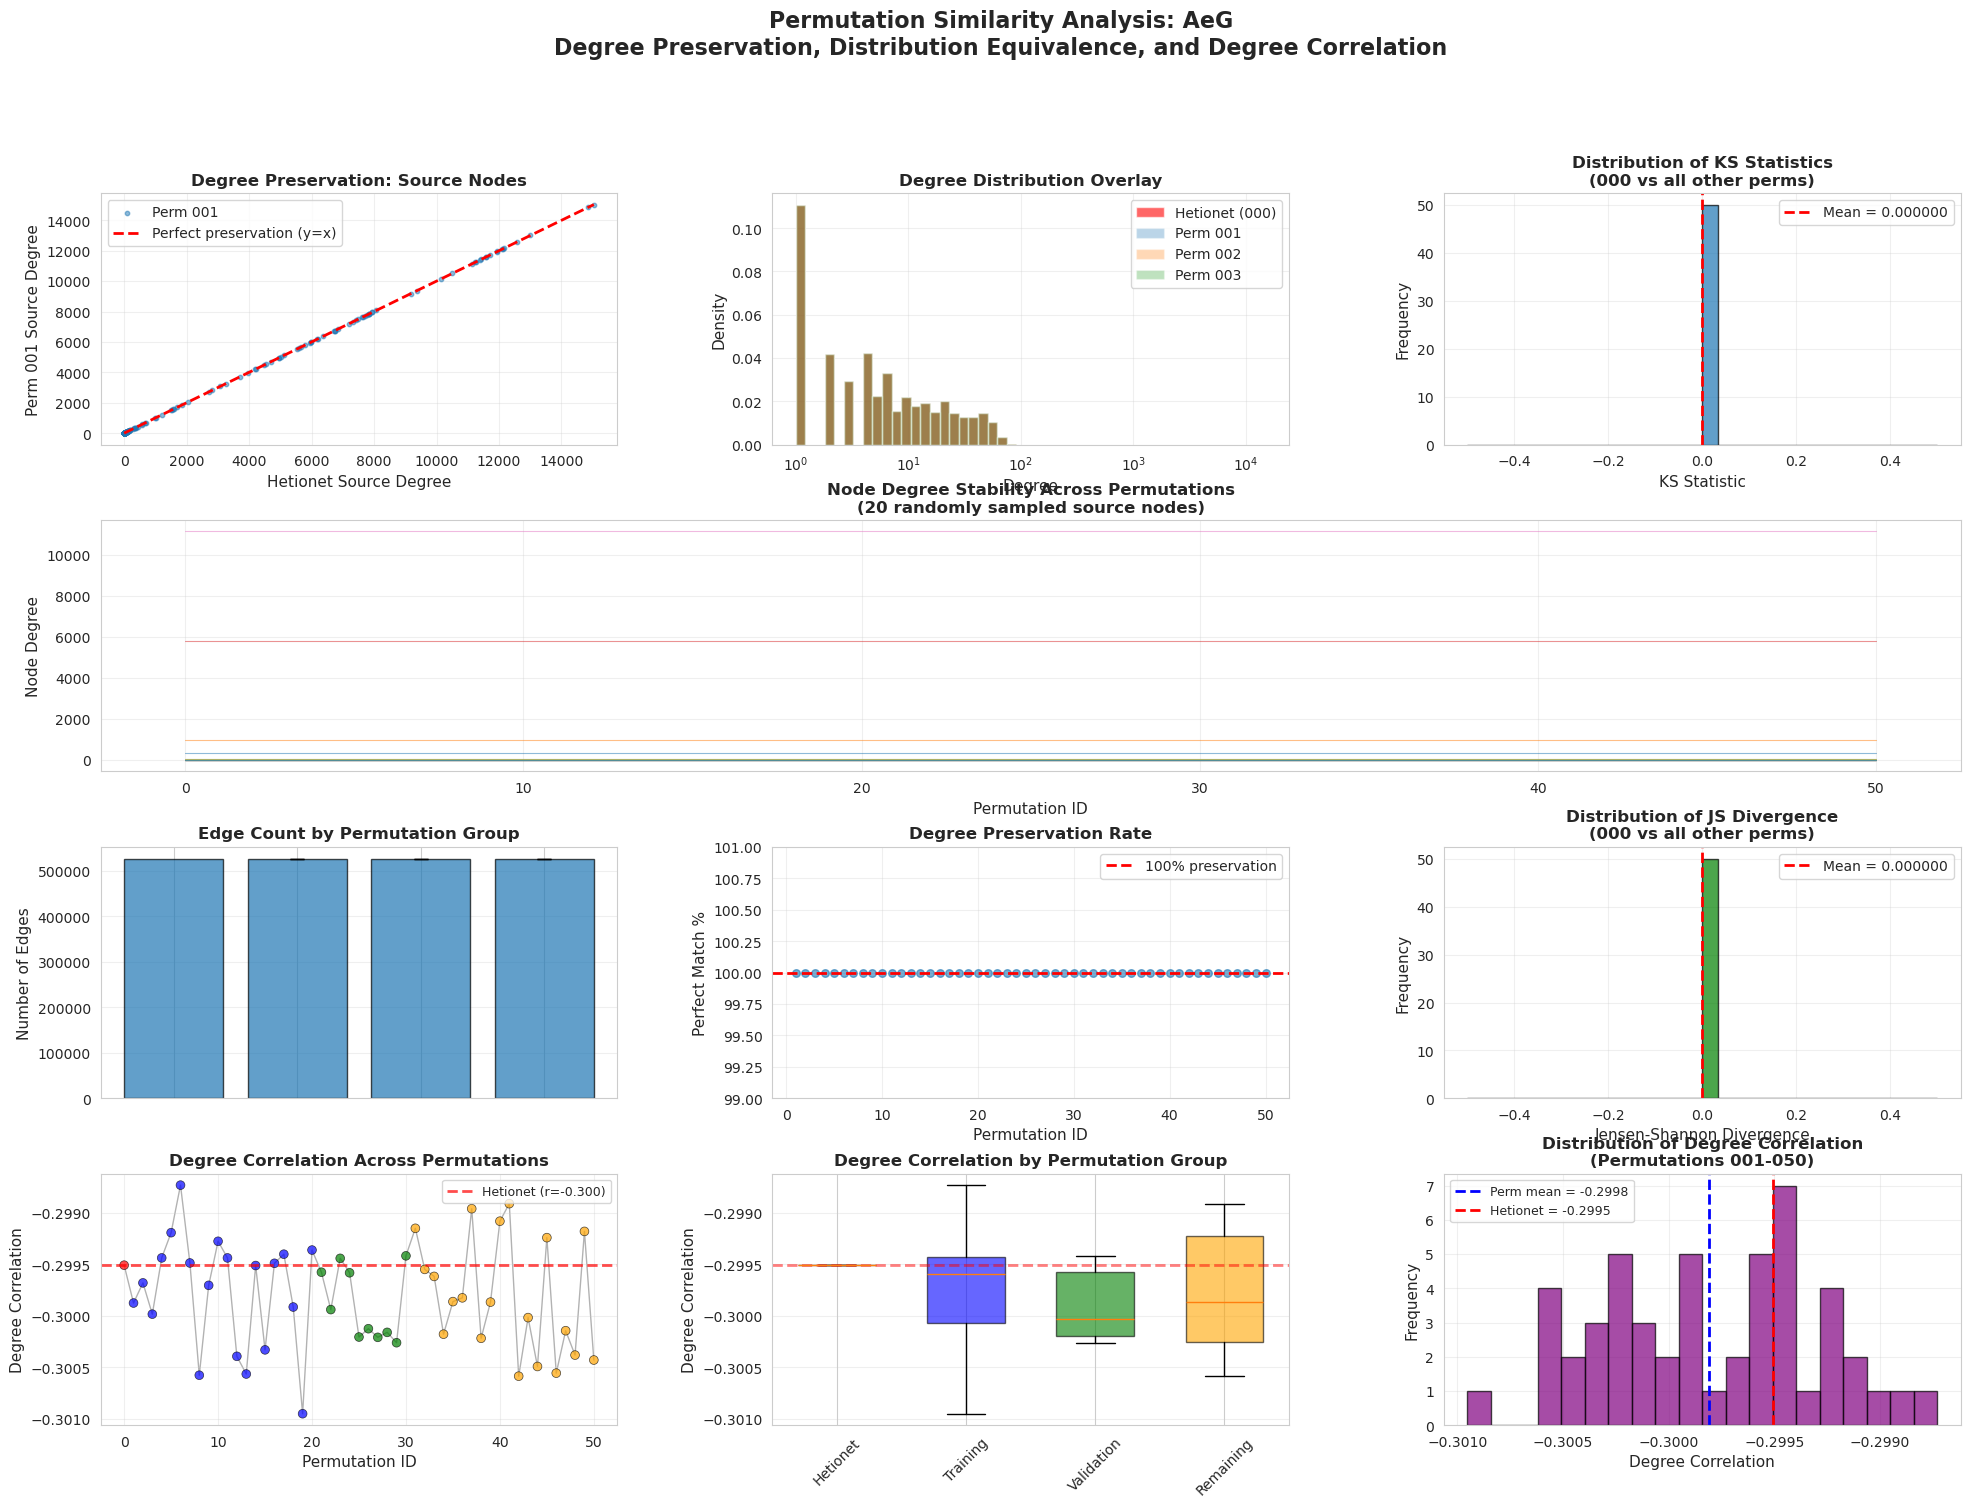


Visualization saved to: /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/permutation_similarity/AeG_permutation_similarity.png


In [13]:
fig = plt.figure(figsize=(24, 16))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
sample_perm = TRAINING_PERMS[0]
perm_source = permutation_data[sample_perm]['source_degrees']
ax1.scatter(het_source_degrees, perm_source, alpha=0.5, s=10, label=f'Perm {sample_perm:03d}')
max_deg = max(het_source_degrees.max(), perm_source.max())
ax1.plot([0, max_deg], [0, max_deg], 'r--', linewidth=2, label='Perfect preservation (y=x)')
ax1.set_xlabel('Hetionet Source Degree', fontsize=11)
ax1.set_ylabel(f'Perm {sample_perm:03d} Source Degree', fontsize=11)
ax1.set_title('Degree Preservation: Source Nodes', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
bins = np.logspace(0, np.log10(het_all_degrees.max() + 1), 50)
ax2.hist(het_all_degrees, bins=bins, alpha=0.6, label='Hetionet (000)', color='red', density=True)
for perm_id in TRAINING_PERMS[:3]:
    perm_degrees = np.concatenate([permutation_data[perm_id]['source_degrees'], 
                                   permutation_data[perm_id]['target_degrees']])
    ax2.hist(perm_degrees, bins=bins, alpha=0.3, density=True, label=f'Perm {perm_id:03d}')
ax2.set_xlabel('Degree', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_xscale('log')
ax2.set_title('Degree Distribution Overlay', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(similarity_df['ks_statistic'], bins=30, edgecolor='black', alpha=0.7)
ax3.axvline(similarity_df['ks_statistic'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean = {similarity_df["ks_statistic"].mean():.6f}')
ax3.set_xlabel('KS Statistic', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Distribution of KS Statistics\n(000 vs all other perms)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, :])
sample_nodes = np.random.choice(len(het_source_degrees), size=min(20, len(het_source_degrees)), replace=False)
for node_idx in sample_nodes:
    degrees_across_perms = [permutation_data[pid]['source_degrees'][node_idx] 
                           for pid in ALL_PERMS_TO_ANALYZE]
    ax4.plot(ALL_PERMS_TO_ANALYZE, degrees_across_perms, alpha=0.5, linewidth=0.8)
ax4.set_xlabel('Permutation ID', fontsize=11)
ax4.set_ylabel('Node Degree', fontsize=11)
ax4.set_title('Node Degree Stability Across Permutations\n(20 randomly sampled source nodes)', 
             fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[2, 0])
edge_counts_by_group = global_stats_df.groupby('group')['n_edges'].agg(['mean', 'std'])
x_pos = np.arange(len(edge_counts_by_group))
ax5.bar(x_pos, edge_counts_by_group['mean'], yerr=edge_counts_by_group['std'], 
        alpha=0.7, edgecolor='black', capsize=5)
ax5.set_xticks(x_pos)
ax5.set_xticklabels(edge_counts_by_group.index, rotation=45, ha='right')
ax5.set_ylabel('Number of Edges', fontsize=11)
ax5.set_title('Edge Count by Permutation Group', fontsize=12, fontweight='bold')
ax5.set_xticklabels([])
ax5.grid(alpha=0.3, axis='y')

ax6 = fig.add_subplot(gs[2, 1])
ax6.scatter(preservation_df['perm_id'], preservation_df['perfect_match_pct'], alpha=0.6, s=30)
ax6.axhline(100, color='red', linestyle='--', linewidth=2, label='100% preservation')
ax6.set_xlabel('Permutation ID', fontsize=11)
ax6.set_ylabel('Perfect Match %', fontsize=11)
ax6.set_title('Degree Preservation Rate', fontsize=12, fontweight='bold')
ax6.set_ylim([99, 101] if preservation_df['perfect_match_pct'].min() > 99 else None)
ax6.legend()
ax6.grid(alpha=0.3)

ax7 = fig.add_subplot(gs[2, 2])
ax7.hist(similarity_df['js_divergence'], bins=30, edgecolor='black', alpha=0.7, color='green')
ax7.axvline(similarity_df['js_divergence'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean = {similarity_df["js_divergence"].mean():.6f}')
ax7.set_xlabel('Jensen-Shannon Divergence', fontsize=11)
ax7.set_ylabel('Frequency', fontsize=11)
ax7.set_title('Distribution of JS Divergence\n(000 vs all other perms)', fontsize=12, fontweight='bold')
ax7.legend()
ax7.grid(alpha=0.3)

# Degree correlation time series
ax8 = fig.add_subplot(gs[3, 0])
colors = degree_correlation_df['group'].map({
    'Hetionet': 'red',
    'Training (001-020)': 'blue',
    'Validation (021-030)': 'green',
    'Remaining (031-050)': 'orange'
})
ax8.scatter(degree_correlation_df['perm_id'], degree_correlation_df['degree_correlation'], 
           c=colors, alpha=0.7, s=40, edgecolors='black', linewidth=0.5)
ax8.plot(degree_correlation_df['perm_id'], degree_correlation_df['degree_correlation'], 
         'k-', alpha=0.3, linewidth=1, zorder=0)
het_degree_corr = degree_correlation_df.loc[degree_correlation_df['perm_id'] == 0, 'degree_correlation'].values[0]
ax8.axhline(het_degree_corr, color='red', linestyle='--', linewidth=2, 
           alpha=0.7, label=f'Hetionet (r={het_degree_corr:.3f})')
ax8.set_xlabel('Permutation ID', fontsize=11)
ax8.set_ylabel('Degree Correlation', fontsize=11)
ax8.set_title('Degree Correlation Across Permutations', fontsize=12, fontweight='bold')
ax8.legend(fontsize=9)
ax8.grid(alpha=0.3)

# Degree correlation by group (box plot)
ax9 = fig.add_subplot(gs[3, 1])
group_order = ['Hetionet', 'Training (001-020)', 'Validation (021-030)', 'Remaining (031-050)']
degree_corr_by_group = [degree_correlation_df[degree_correlation_df['group'] == g]['degree_correlation'].values 
                        for g in group_order if g in degree_correlation_df['group'].values]
bp = ax9.boxplot(degree_corr_by_group, labels=[g.split()[0] for g in group_order if g in degree_correlation_df['group'].values],
                patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], ['red', 'blue', 'green', 'orange']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax9.axhline(het_degree_corr, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax9.set_ylabel('Degree Correlation', fontsize=11)
ax9.set_title('Degree Correlation by Permutation Group', fontsize=12, fontweight='bold')
ax9.tick_params(axis='x', rotation=45)
ax9.grid(alpha=0.3, axis='y')

# Degree correlation histogram
ax10 = fig.add_subplot(gs[3, 2])
perm_degree_corr = degree_correlation_df[degree_correlation_df['perm_id'] > 0]['degree_correlation']
ax10.hist(perm_degree_corr, bins=20, edgecolor='black', alpha=0.7, color='purple')
ax10.axvline(perm_degree_corr.mean(), color='blue', linestyle='--', linewidth=2, 
            label=f'Perm mean = {perm_degree_corr.mean():.4f}')
ax10.axvline(het_degree_corr, color='red', linestyle='--', linewidth=2, 
            label=f'Hetionet = {het_degree_corr:.4f}')
ax10.set_xlabel('Degree Correlation', fontsize=11)
ax10.set_ylabel('Frequency', fontsize=11)
ax10.set_title('Distribution of Degree Correlation\n(Permutations 001-050)', fontsize=12, fontweight='bold')
ax10.legend(fontsize=9)
ax10.grid(alpha=0.3)

plt.suptitle(f'Permutation Similarity Analysis: {EDGE_TYPE}\nDegree Preservation, Distribution Equivalence, and Degree Correlation', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig(results_dir / f'{EDGE_TYPE}_permutation_similarity.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {results_dir / f'{EDGE_TYPE}_permutation_similarity.png'}")

## 8. Statistical Summary and Conclusions

In [11]:
print("\n" + "="*80)
print("PERMUTATION SIMILARITY ANALYSIS SUMMARY")
print("="*80)
print(f"\nEdge Type: {EDGE_TYPE}")
print(f"Reference: Permutation 000 (Hetionet)")
print(f"Permutations Analyzed: {len(ALL_PERMS_TO_ANALYZE)}")
print(f"  - Training set (001-020): {len(TRAINING_PERMS)}")
print(f"  - Validation set (021-030): {len(VALIDATION_PERMS)}")
print(f"  - Remaining set (031-050): {len(REMAINING_PERMS)}")

print(f"\n{'='*80}")
print("DEGREE SEQUENCE PRESERVATION")
print("="*80)
print(f"Perfect match rate: {preservation_df['perfect_match_pct'].mean():.4f}%")
print(f"Mean degree deviation: {preservation_df['mean_abs_deviation'].mean():.6f}")
print(f"Max degree deviation: {preservation_df['max_abs_deviation'].max():.1f}")

print(f"\n{'='*80}")
print("DEGREE DISTRIBUTION SIMILARITY")
print("="*80)
print(f"Mean KS statistic (000 vs others): {similarity_df['ks_statistic'].mean():.6f}")
print(f"Mean KS p-value: {similarity_df['ks_pvalue'].mean():.6f}")
print(f"Mean JS divergence: {similarity_df['js_divergence'].mean():.6f}")
print(f"Mean Earth Mover's Distance: {similarity_df['emd'].mean():.6f}")

print(f"\n{'='*80}")
print("BIPARTITE DEGREE CORRELATION")
print("="*80)
het_degree_corr = degree_correlation_df.loc[degree_correlation_df['perm_id'] == 0, 'degree_correlation'].values[0]
perm_degree_corr = degree_correlation_df[degree_correlation_df['perm_id'] > 0]['degree_correlation']
print(f"Hetionet (000): {het_degree_corr:.6f}")
print(f"Permutations: {perm_degree_corr.mean():.6f} +/- {perm_degree_corr.std():.6f}")
print(f"Range: [{perm_degree_corr.min():.6f}, {perm_degree_corr.max():.6f}]")
print(f"Coefficient of variation: {perm_degree_corr.std() / abs(perm_degree_corr.mean()):.4f}")

print(f"\n{'='*80}")
print("EDGE COUNT CONSISTENCY")
print("="*80)
print(f"Hetionet (000): {global_stats_df.loc[0, 'n_edges']:,} edges")
print(f"All permutations: {global_stats_df['n_edges'].mean():,.2f} +/- {global_stats_df['n_edges'].std():.6f}")
print(f"Range: [{global_stats_df['n_edges'].min():,}, {global_stats_df['n_edges'].max():,}]")

print(f"\n{'='*80}")
print("GROUP COMPARISON")
print("="*80)
train_ks = similarity_df[similarity_df['perm_id'].isin(TRAINING_PERMS)]['ks_statistic'].mean()
valid_ks = similarity_df[similarity_df['perm_id'].isin(VALIDATION_PERMS)]['ks_statistic'].mean()
print(f"Mean KS (000 vs Training): {train_ks:.6f}")
print(f"Mean KS (000 vs Validation): {valid_ks:.6f}")
print(f"Difference: {abs(train_ks - valid_ks):.6f}")

train_degree_corr = degree_correlation_df[degree_correlation_df['perm_id'].isin(TRAINING_PERMS)]['degree_correlation'].mean()
valid_degree_corr = degree_correlation_df[degree_correlation_df['perm_id'].isin(VALIDATION_PERMS)]['degree_correlation'].mean()
print(f"\nMean degree correlation (Training): {train_degree_corr:.6f}")
print(f"Mean degree correlation (Validation): {valid_degree_corr:.6f}")
print(f"Difference: {abs(train_degree_corr - valid_degree_corr):.6f}")

print(f"\n{'='*80}")
print("CONCLUSIONS")
print("="*80)

all_perfect = preservation_df['perfect_match_pct'].min() == 100.0
tiny_ks = similarity_df['ks_statistic'].max() < 0.01
tiny_js = similarity_df['js_divergence'].max() < 0.01
zero_edge_variance = global_stats_df['n_edges'].std() == 0
proper_variation = 0.001 < perm_degree_corr.std() < 0.05

if all_perfect and tiny_ks and tiny_js and zero_edge_variance:
    print("\nPERFECT STRUCTURAL EQUIVALENCE CONFIRMED")
    print("\nAll permutations are structurally identical:")
    print("  1. Every node has identical degree across all permutations")
    print("  2. Degree distributions are statistically indistinguishable")
    print("  3. Edge counts are perfectly preserved")
    print("  4. No systematic differences between permutation groups")
    
    if proper_variation:
        print("  5. Degree correlation shows proper variation (edge randomization working)")
    
    print("\nXSwap algorithm successfully preserves:")
    print("  - Degree sequence (exact)")
    print("  - Degree distribution (identical)")
    print("  - Edge count (constant)")
    print("  - Global graph properties (moments, extrema)")
    
    if het_degree_corr < -0.1:
        print(f"\nNetwork structure: DISASSORTATIVE-LIKE (r = {het_degree_corr:.3f})")
        print("  High-degree nodes connect to low-degree nodes")
        print("  Common pattern in biological networks")
    elif het_degree_corr > 0.1:
        print(f"\nNetwork structure: ASSORTATIVE-LIKE (r = {het_degree_corr:.3f})")
        print("  High-degree nodes connect to other high-degree nodes")
    else:
        print(f"\nNetwork structure: NON-ASSORTATIVE (r approx {het_degree_corr:.3f})")
        print("  Random mixing pattern")
    
    print("\nThe ONLY difference between permutations is which specific edges exist.")
    print("Permutations are valid null models for degree-conditioned analyses.")
elif all_perfect and (tiny_ks or tiny_js):
    print("\nEXCELLENT STRUCTURAL EQUIVALENCE")
    print("  Degree sequences perfectly preserved")
    print("  Distributions nearly identical (small numerical differences)")
    
    if proper_variation:
        print("  Degree correlation shows proper variation")
    
    print("  XSwap working correctly")
else:
    print("\nSTRUCTURAL DIFFERENCES DETECTED")
    if not all_perfect:
        print(f"  - Degree preservation issues (match rate: {preservation_df['perfect_match_pct'].min():.2f}%)")
    if not tiny_ks:
        print(f"  - Distribution differences (max KS: {similarity_df['ks_statistic'].max():.4f})")
    if not zero_edge_variance:
        print(f"  - Edge count variation (std: {global_stats_df['n_edges'].std():.2f})")
    if not proper_variation:
        print(f"  - Degree correlation variation abnormal (std: {perm_degree_corr.std():.6f})")
    print("  - Investigate XSwap implementation or data loading")

print(f"\n{'='*80}")


PERMUTATION SIMILARITY ANALYSIS SUMMARY

Edge Type: AeG
Reference: Permutation 000 (Hetionet)
Permutations Analyzed: 51
  - Training set (001-020): 20
  - Validation set (021-030): 10
  - Remaining set (031-050): 20

DEGREE SEQUENCE PRESERVATION
Perfect match rate: 100.0000%
Mean degree deviation: 0.000000
Max degree deviation: 0.0

DEGREE DISTRIBUTION SIMILARITY
Mean KS statistic (000 vs others): 0.000000
Mean KS p-value: 1.000000
Mean JS divergence: 0.000000
Mean Earth Mover's Distance: 0.000000

BIPARTITE DEGREE CORRELATION
Hetionet (000): -0.299508
Permutations: -0.299810 +/- 0.000519
Range: [-0.300952, -0.298730]
Coefficient of variation: 0.0017

EDGE COUNT CONSISTENCY
Hetionet (000): 526,407 edges
All permutations: 526,407.00 +/- 0.000000
Range: [526,407, 526,407]

GROUP COMPARISON
Mean KS (000 vs Training): 0.000000
Mean KS (000 vs Validation): 0.000000
Difference: 0.000000

Mean degree correlation (Training): -0.299765
Mean degree correlation (Validation): -0.299892
Difference

## 9. Save Results

In [12]:
preservation_df.to_csv(results_dir / f'{EDGE_TYPE}_degree_preservation.csv', index=False)
similarity_df.to_csv(results_dir / f'{EDGE_TYPE}_distribution_similarity.csv', index=False)
global_stats_df.to_csv(results_dir / f'{EDGE_TYPE}_global_statistics.csv', index=False)
degree_correlation_df.to_csv(results_dir / f'{EDGE_TYPE}_degree_correlation.csv', index=False)

het_degree_corr = degree_correlation_df.loc[degree_correlation_df['perm_id'] == 0, 'degree_correlation'].values[0]
perm_degree_corr = degree_correlation_df[degree_correlation_df['perm_id'] > 0]['degree_correlation']

summary_stats = {
    'edge_type': EDGE_TYPE,
    'n_permutations_analyzed': len(ALL_PERMS_TO_ANALYZE),
    'hetionet_edges': int(global_stats_df.loc[0, 'n_edges']),
    'perfect_degree_match_pct': float(preservation_df['perfect_match_pct'].mean()),
    'mean_degree_deviation': float(preservation_df['mean_abs_deviation'].mean()),
    'max_degree_deviation': float(preservation_df['max_abs_deviation'].max()),
    'mean_ks_statistic': float(similarity_df['ks_statistic'].mean()),
    'max_ks_statistic': float(similarity_df['ks_statistic'].max()),
    'mean_js_divergence': float(similarity_df['js_divergence'].mean()),
    'mean_emd': float(similarity_df['emd'].mean()),
    'edge_count_std': float(global_stats_df['n_edges'].std()),
    'training_ks_mean': float(similarity_df[similarity_df['perm_id'].isin(TRAINING_PERMS)]['ks_statistic'].mean()),
    'validation_ks_mean': float(similarity_df[similarity_df['perm_id'].isin(VALIDATION_PERMS)]['ks_statistic'].mean()),
    'hetionet_degree_correlation': float(het_degree_corr),
    'perm_degree_correlation_mean': float(perm_degree_corr.mean()),
    'perm_degree_correlation_std': float(perm_degree_corr.std()),
    'perm_degree_correlation_min': float(perm_degree_corr.min()),
    'perm_degree_correlation_max': float(perm_degree_corr.max()),
    'training_degree_correlation_mean': float(degree_correlation_df[degree_correlation_df['perm_id'].isin(TRAINING_PERMS)]['degree_correlation'].mean()),
    'validation_degree_correlation_mean': float(degree_correlation_df[degree_correlation_df['perm_id'].isin(VALIDATION_PERMS)]['degree_correlation'].mean())
}

with open(results_dir / f'{EDGE_TYPE}_summary.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print("Results saved:")
print(f"  - {results_dir / f'{EDGE_TYPE}_degree_preservation.csv'}")
print(f"  - {results_dir / f'{EDGE_TYPE}_distribution_similarity.csv'}")
print(f"  - {results_dir / f'{EDGE_TYPE}_global_statistics.csv'}")
print(f"  - {results_dir / f'{EDGE_TYPE}_degree_correlation.csv'}")
print(f"  - {results_dir / f'{EDGE_TYPE}_summary.json'}")
print(f"  - {results_dir / f'{EDGE_TYPE}_permutation_similarity.png'}")
print(f"\nAnalysis complete!")

Results saved:
  - /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/permutation_similarity/AeG_degree_preservation.csv
  - /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/permutation_similarity/AeG_distribution_similarity.csv
  - /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/permutation_similarity/AeG_global_statistics.csv
  - /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/permutation_similarity/AeG_degree_correlation.csv
  - /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/permutation_similarity/AeG_summary.json
  - /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/permutation_similarity/AeG_permutation_similarity.png

Analysis complete!
